This notebook is to generate the new connected datframe and save it to my desktop. 


Questions for antoine: 
- My kernal keeps crashing and idk why.

To load the dataset only one time. (Takes 1min 23 sec)
The full dataset is called df, and is used in later code blocks. 
Run the whole script to load the correct way. 

In [1]:
from LoadingDataset import *

df = loading_dataframe() 

print(df)

--Start loading dataset--
Trial: 20
Trial: 40
Trial: 60
--Finished loading dataset--
{'Trial_1':                                                            x  \
Track_1    (0.4915617336887338, 0.4888074121724598, 0.486...   
Track_2    (0.07535657655896169, 0.07526330296058384, 0.0...   
Track_3    (-0.006486002252066885, -0.004220824105546397,...   
Track_4    (0.021859353573039565, 0.022673805219507563, 0...   
Track_5    (0.19961463161498894, 0.19353493255753446, 0.1...   
...                                                      ...   
Track_763  (0.49595540066386967, 0.49420279223477853, 0.4...   
Track_764  (0.06221520056628922, 0.05901417153809262, 0.0...   
Track_765  (0.4872640757082221, 0.48428140313747137, 0.48...   
Track_766  (-0.005598267563186496, -0.0027471336071438323...   
Track_767  (-0.1295784532886579, -0.12693338723706607, -0...   

                                                           y  \
Track_1    (-0.3448935800538012, -0.3425020216992051, -0....   
Track_

Acces a track.

x --> df['Trial_1'].loc['Track_1'][0] or df['Trial_1'].loc['Track_1', 'x']

y --> df['Trial_1'].loc['Track_1'][1] or df['Trial_1'].loc['Track_1', 'z']

z --> df['Trial_1'].loc['Track_1'][2] or df['Trial_1'].loc['Track_1', 'y']

time --> df['Trial_1'].loc['Track_1'][3] or df['Trial_1'].loc['Track_1', 'time']

In [2]:
df['Trial_10'].loc['Track_6']

x       (-0.4802723191159874, -0.47263961920878894, -0...
y       (-0.028486223927734772, -0.02355766121061059, ...
z       (0.5484372752921228, 0.5438705716555217, 0.539...
time    (199.0888888888889, 199.1, 199.11111111111111,...
Name: Track_6, dtype: object

Added column that tells if the track has landed. 
To call the landed column: df['Trial_1']['landed']
Loop trhough this coumn: for track_name, landed_status in df['Trial_1']['landed'].items():
To ask if a specific track is landed: df['Trial_1'].loc['Track_1', 'landed'] --> true or false. 

Same goes for take-off

In [3]:
from supportive_functions import landing_area
for trial_num in range(1,65): 
    landed = []
    for track_name, track_data in df[f'Trial_{trial_num}'].iterrows():
        # Get last position and time values
        last_x = track_data['x'][-1]
        last_y = track_data['y'][-1]
        last_z = track_data['z'][-1]
        
        # Check if landed
        landed.append(landing_area(last_x, last_y, last_z))
        
    # Add the 'landed' column to the DataFrame (same value for all rows)
    trial_df = df[f'Trial_{trial_num}']
    trial_df['landed'] = landed
    df[f'Trial_{trial_num}'] = trial_df

for track_name, landed_status in df['Trial_1']['landed'].items():       
    if landed_status: 
        print(track_name, landed_status)

Track_34 True
Track_41 True
Track_43 True
Track_125 True
Track_134 True
Track_216 True
Track_265 True
Track_339 True
Track_386 True
Track_395 True
Track_449 True
Track_462 True
Track_463 True
Track_490 True
Track_516 True
Track_535 True
Track_550 True
Track_553 True
Track_568 True
Track_575 True
Track_576 True
Track_578 True
Track_593 True
Track_664 True
Track_682 True
Track_685 True
Track_687 True
Track_688 True
Track_689 True


In [4]:
from supportive_functions import landing_area
for trial_num in range(1,65): 
    take_off = []
    for track_name, track_data in df[f'Trial_{trial_num}'].iterrows():
        # Get last position and time values
        first_x = track_data['x'][0]
        first_y = track_data['y'][0]
        first_z = track_data['z'][0]
        
        # Check if landed
        take_off.append(landing_area(first_x, first_y, first_z))
        
    # Add the 'landed' column to the DataFrame (same value for all rows)
    trial_df = df[f'Trial_{trial_num}']
    trial_df['take_off'] = take_off
    df[f'Trial_{trial_num}'] = trial_df

count = 0 
for track_name, take_off_status in df['Trial_1']['take_off'].items():       
    if take_off_status: 
        count += 1

if count == 42: 
    print('This function works for Trial 1')


This function works for Trial 1


Generating the pairs connecting the landings with the take-offs. 
Per landing it checks if there is a take-off assosiated with it within the radius boundary. 
If multiple points are found, it chooses the closest take-off to the landing point. 
If this take-off is already used once, it checks if the pair has a shorter distance between them. If so, the pair gets replaced. 

Can be optimised by checking the next point, if a point does not get replaced. ! (Not done that just yet) 

In [ ]:
def generating_pairs(trial_num, radius = 0.2):  
        pairs=[]
        for track_name, track_data in df[f'Trial_{trial_num}'].iterrows():
            potential_pairs = []
            if track_data['landed']: 
                last_x, last_y, last_z, last_time = track_data['x'][-1], track_data['y'][-1], track_data['z'][-1], track_data['time'][-1]
                for track_name2, track_data2 in df[f'Trial_{trial_num}'].iterrows():
                    if track_data2['take_off']: 
                        first_x, first_y, first_z, first_time = track_data2['x'][0], track_data2['y'][0], track_data2['z'][0], track_data2['time'][0]
                        dx, dy, dz, dtime = (first_x - last_x), (first_y - last_y), (first_z - last_z), (first_time - last_time)
                        distance = np.sqrt((dx ** 2) + (dy ** 2) + (dz ** 2))
                        if (distance < radius and dtime > 0):
                            potential_pairs.append((distance,track_name, track_name2))
            if potential_pairs: 
                closest_pair = potential_pairs[0] # only choose the closest take-off to the landing point
                if pairs: 
                    found_match = False
                    for i, pair in enumerate(pairs): 
                        if closest_pair[2] == pair[2]: # check if there are similar take-off tracks already saved
                            found_match = True
                            if closest_pair[0] < pair[0]: # check if new pair as a shorter distance then existing pair in pairs list. 
                                pairs[i] = closest_pair # replacing existing pair with newer pair. 
                    if not found_match: 
                        pairs.append(closest_pair)
                else: 
                    pairs.append(closest_pair)
        return pairs

#testing if the function works: testing for duplicate tracks in the list
trial_num = 5
landing_list, take_off_list = [], []
for pair in generating_pairs(trial_num): 
    distance, track_name1, track_name2 = pair 
    landing_list.append(track_name1)
    take_off_list.append(track_name1)
duplicates_landing = {t for t in landing_list if landing_list.count(t) > 1}
duplicates_take_off = {t for t in take_off_list if take_off_list.count(t) > 1}
if duplicates_landing or duplicates_take_off: 
    print(f'Not working: There are duplicate tracks')
    if duplicates_landing: 
        print('Fault in landings')
    else: 
        print('fault in take-offs')
else: 
    print('Function working: There are no duplicates')
    


Function working: There are no duplicates
fault in take-offs


Now check iff the landings also begin in a take_off we found earlyer. Or that a take_off ands in a landing we found earlyer. 
I make a chain of tracks that connect together. 

In [ ]:
def generating_pairs_complex(trial_num, radius = 0.2): 
    pairs = generating_pairs(trial_num, radius = radius)
    connection_map = {landing: takeoff for _, landing, takeoff in pairs}
    used_tracks = set()
    chains = []
    for _, start, end in pairs:
        if start not in used_tracks:
            chain = [start]
            used_tracks.add(start)
            current = start
            next_track = connection_map.get(current)
            while next_track is not None and next_track not in used_tracks:
                chain.append(next_track)
                used_tracks.add(next_track)

                current = next_track
                next_track = connection_map.get(current)
            chains.append(chain)
    return chains 



#testing if the function works: testing for duplicate tracks in the list
trial_num = 5
all_tracks = [track for chain in generating_pairs_complex(trial_num) for track in chain]
duplicates = {t for t in all_tracks if all_tracks.count(t) > 1}
if duplicates: 
    print(f'Not working: There are duplicate tracks')
else: 
    print('Working: There are no duplicates')

Not working: There are no duplicates


Adding the pairs together in a new dataframe/dictionary and saving that dictionary in joblib. 

Problem is that if there is a track that begins in take-off and ends in landing, what then? It coppies the data double. 
First create a full list of al the tacks that need to merdge, with some lists of multiple (more than 2) tracks. 



In [ ]:
import joblib 
import os
merged_df = {}

for trial_num, trial_df in enumerate(df):
    trial_num += 1
    trial_key = f'Trial_{trial_num}'
    if trial_key not in merged_df:
        merged_df[trial_key] = pd.DataFrame(columns=['x', 'y', 'z', 'time'])
    chains = generating_pairs_complex(trial_num)
    for chain_idx, chain in enumerate(chains):
        merged_track_name = f"Merged_Chain_{chain_idx + 1}"
        merged_x = tuple(x for track in chain for x in df[f'Trial_{trial_num}'].loc[track, 'x'])
        merged_y = tuple(y for track in chain for y in df[f'Trial_{trial_num}'].loc[track, 'y'])
        merged_z = tuple(z for track in chain for z in df[f'Trial_{trial_num}'].loc[track, 'z'])
        merged_time = tuple(t for track in chain for t in df[f'Trial_{trial_num}'].loc[track, 'time'])

        merged_df[trial_key].at[f'{merged_track_name}', 'x'] = merged_x
        merged_df[trial_key].at[f'{merged_track_name}', 'y'] = merged_y
        merged_df[trial_key].at[f'{merged_track_name}', 'z'] = merged_z
        merged_df[trial_key].at[f'{merged_track_name}', 'time'] = merged_time

dataset_path = '/Users/nubia/Desktop/Thesis_2.0/dataset'
save_path = os.path.join(dataset_path, "merged_df.joblib")
joblib.dump(merged_df, save_path)

print(f"Data saved to: {save_path}")


{'Trial_1':                                                                  x  \
Merged_Chain_1   (0.13109038063981565, 0.1314632466490117, 0.13...   
Merged_Chain_2   (-0.0053190137320291335, -0.003387836440779575...   
Merged_Chain_3   (0.06454513580580884, 0.0655194773344161, 0.06...   
Merged_Chain_4   (0.16082209409509174, 0.1588910372345636, 0.15...   
Merged_Chain_5   (0.03766388666906581, 0.0374563528808922, 0.03...   
Merged_Chain_6   (-0.20605275683081936, -0.20594699229910252, -...   
Merged_Chain_7   (-0.028362697316931584, -0.035541956932801294,...   
Merged_Chain_8   (0.0506713115847191, 0.049610465200581294, 0.0...   
Merged_Chain_9   (-0.19240224065490935, -0.19068920105732373, -...   
Merged_Chain_10  (0.17544471689338045, 0.1767997850846826, 0.17...   
Merged_Chain_11  (0.13310875802896738, 0.13079203224810204, 0.1...   

                                                                 y  \
Merged_Chain_1   (0.3175434780365281, 0.3140491073526424, 0.310...   
Merged_

From this point onward, it was just some testing: 

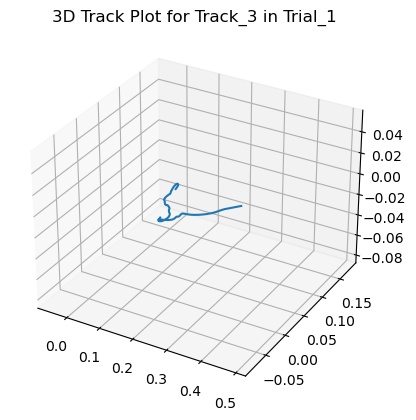

In [8]:
from matplotlib import pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Extract the data for Track_3
x = df['Trial_1'].loc['Track_3', 'x']
y = df['Trial_1'].loc['Track_3', 'y']
z = df['Trial_1'].loc['Track_3', 'z']

# Plot the 3D line
ax.plot(x, y, z)

ax.set_title('3D Track Plot for Track_3 in Trial_1')

plt.show()